In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.analysis

In [2]:
modes=['BandRemoval:4', 'BandRemoval:2', 'SuperFOV', 'SyntheticBanding']
model_dir = "D:/DeepSSFP/"
model_name="knee_study"

100%|██████████| 4/4 [00:08<00:00,  2.20s/it]


Dataset loaded: (2560, 416, 416, 8)
Memory size: 7.08837376 GB
Dataset shape: (2560, 416, 416, 8)
Formatting data for SyntheticBanding mode...
Data format complete.
Input shape: (2560, 416, 416, 4), Output shape: (2560, 416, 416, 4)
Selected indices: [1335 2042]
Figure size: (8, 4)


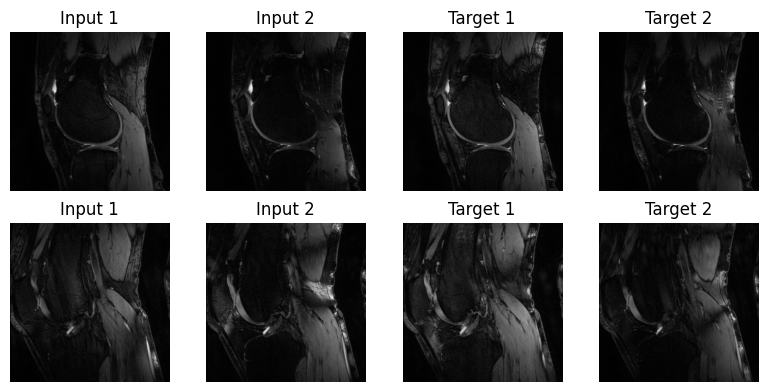

In [ ]:
import deepssfp.dataloader
import deepssfp.dataformatter

path = 'D:/MRI/2024_Krithika_KneeStudy'

filters = [
    'HV1_lk_r1', 'HV2_lk_r1', 'HV3_lk_r1', 'HV4_lk_r1', 'HV5_lk_r1', 'HV6_lk_r1', 'HV7_lk_r1', 'HV8_lk_r1',
    'HV1_lk_r2', 'HV2_lk_r2', 'HV3_lk_r2', 'HV4_lk_r2', 'HV5_lk_r2', 'HV6_lk_r2', 'HV7_lk_r2', 'HV8_lk_r2',
    'HV1_rk_r1', 'HV2_rk_r1', 'HV3_rk_r1', 'HV4_rk_r1', 'HV5_rk_r1', 'HV6_rk_r1', 'HV7_rk_r1', 'HV8_rk_r1',
    'HV1_rk_r2', 'HV2_rk_r2', 'HV3_rk_r2', 'HV4_rk_r2', 'HV5_rk_r2', 'HV6_rk_r2', 'HV7_rk_r2', 'HV8_rk_r2']

dataset = deepssfp.dataloader.read_complex_dicom_datasets(path, filters = filters)
print(f"Dataset shape: {dataset['M'].shape}")
input, output = deepssfp.dataformatter.format_synthetic_banding_for_realimag_data(dataset['M'])
print(f"Input shape: {input.shape}, Output shape: {output.shape}")

deepssfp.visualize_images(
    input_images=input,

    target_images=output,
    num_samples=2,
)

Info: Data all ready formated.
Dataset: mode:SyntheticBanding, size:2560 height:416 width:416 cin:4 cout:4 ratio:0.8
dtype: float16, float16
Using same scaler for SyntheticBanding mode
Training DataSet: (2048, 416, 416, 4) | (2048, 416, 416, 4)
Test DataSet: (512, 416, 416, 4) | (512, 416, 416, 4)
Selected indices: [166  48]
Figure size: (8, 4)


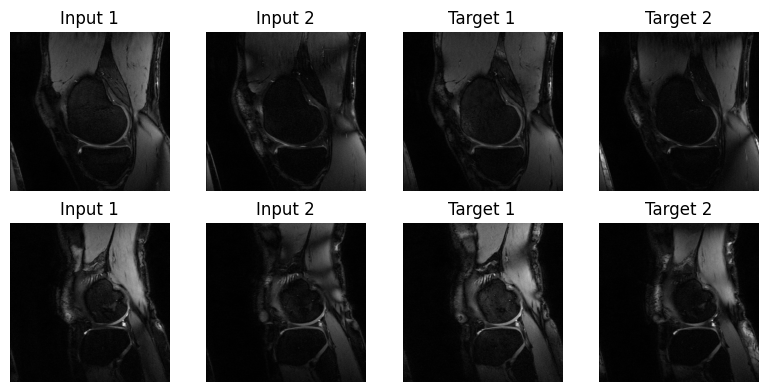

In [4]:
del dataset
ds = deepssfp.dataset.Dataset('SyntheticBanding', input_data=input, output_data=output, stats_fraction=0.1)

del input
del output

print(f"Training DataSet: {ds.x_train.shape} | {ds.y_train.shape}")
print(f"Test DataSet: {ds.x_test.shape} | {ds.y_test.shape}")

deepssfp.visualize_images(
    input_images=ds.x_test,
    target_images=ds.y_test,
    num_samples=2,
)

In [ ]:
import deepssfp.analysis
results = deepssfp.analysis.run_training(
    mode=deepssfp.DataMode.SyntheticBanding.value, 
    model_name=model_name,
    model_dir=model_dir,
    train_model=True,
    ds=ds,
    #custom_dataset=dataset,
    save_dataset=False,
)